# 🩻 CLARITY: Conversational LLM-Assisted Radiology Interpretation and Transparency

**Research Prototype · Kaggle Notebook**

**References:**  
- Abnar & Zuidema (2020) — Quantifying Attention Flow in Transformers  
- Chefer et al. (2021) — Transformer Interpretability Beyond Attention Visualization  
- Sellergren et al. (2025) — MedGemma Technical Report (arXiv:2507.05201)

---

> ⚠️ **Prerequisites:** Add your HuggingFace token to Kaggle Secrets as `HF_TOKEN` or colab secret.
> Accept the MedGemma terms at huggingface.co/google/medgemma-4b-it before running.  
> Run on **GPU T4 (16 GB)** — required for the forward pass with attention extraction.


In [ ]:
# %%capture install_output
# # Core dependencies — transformers>=4.50.0 required for Gemma 3 / MedGemma
# !pip install -q -U "transformers>=4.50.0" accelerate bitsandbytes
# !pip install -q scipy nltk pillow matplotlib ipywidgets
# !pip install -q huggingface_hub
# print("✓ Installation complete")

In [1]:
import os, gc, re, json, warnings, textwrap
from io import BytesIO
from datetime import datetime

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from PIL import Image
import scipy.ndimage as ndimage
import requests
import nltk
from nltk.tokenize import sent_tokenize
from IPython.display import display, clear_output, HTML
import ipywidgets as widgets

from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
    set_seed,
)
from huggingface_hub import login

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
warnings.filterwarnings("ignore")
set_seed(42)

# ── GPU sanity check ──────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 1e9
    print(f"GPU   : {props.name}")
    print(f"VRAM  : {vram_gb:.1f} GB")
    if vram_gb < 14:
        print("⚠  Warning: < 14 GB VRAM detected. Consider using 4-bit quantization (see CONFIG).")
    else:
        print("✓  VRAM sufficient for attention extraction pass.")
else:
    raise RuntimeError("GPU required. Enable GPU in Kaggle: Settings → Accelerator → GPU T4")

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB
✓  VRAM sufficient for attention extraction pass.


In [68]:
# ═══════════════════════════════════════════════════════════
# CLARITY CONFIG — DIAGNOSTIC INTERPRETATION MODE
# ═══════════════════════════════════════════════════════════

MODEL_ID = "google/medgemma-1.5-4b-it"
QUANT_MODE = "bf16"

N_LAYERS_FROM_END = 6
ATTN_SIGMA        = 1.5
OVERLAY_ALPHA     = 0.50
HEATMAP_CMAP      = "jet"
MAX_NEW_TOKENS    = 500

# Neutralizing the prompt with added specific user constraints
SYSTEM_PROMPT = (
    "Provide a diagnostic interpretation of this clinical image. Output only the requested sections.\n"
    "1. Impression: State the primary medical condition or pathology identified (e.g., Pneumonia, Pleural Effusion, Mass, Pneumothorax). If multiple conditions exist, list them in order of clinical significance.\n"
    "2. Confidence: Score (0-100%).\n"
    "3. Reasoning: Clinical and structural evidence supporting the diagnosis.\n"
    "4. Findings: Describe each anatomical region (lung fields, cardiac silhouette, mediastinum, costophrenic angles, and bones) "
    "in its own single, standalone sentence. Do NOT use bullet points, numbered lists, or bold text. "
    "If a region is normal, explicitly state it is normal. "
    "Do not include introductory text, AI disclaimers, or medical advice warnings."
)

print("✓ Prompt updated for diagnostic interpretation mode")

✓ Prompt updated for diagnostic interpretation mode


if running on kaggle ->

In [ ]:
# # ── HuggingFace authentication ───────────────────────────────────────────────
# # Store your HF token in Kaggle: Add-ons → Secrets → + New Secret
# # Key: HUGGINGFACE_TOKEN   Value: hf_xxxx...
# try:
#     from kaggle_secrets import UserSecretsClient
#     secrets = UserSecretsClient()
#     HF_TOKEN = secrets.get_secret("HUGGINGFACE_TOKEN")
#     login(HF_TOKEN, add_to_git_credential=False)
#     print("✓ HuggingFace login successful (via Kaggle Secrets)")
# except Exception as e:
#     print(f"Kaggle Secrets not found ({e}).")
#     HF_TOKEN = input("Paste your HuggingFace token: ").strip()
#     login(HF_TOKEN, add_to_git_credential=False)

if running on colab ->

In [3]:
from huggingface_hub import login
from google.colab import userdata

try:
  HF_TOKEN = userdata.get("HF_TOKEN")
  login(HF_TOKEN)
  print("Successfully logged in")
except userdata.SecretNotFoundError:
  print("Error: The secret 'HF_TOKEN' was not found in the Secrets sidebar.")
except userdata.NotebookAccessError:
  print("Error: Access to 'HF_TOKEN' is not enabled for this notebook. Toggle it 'ON' in the Secrets sidebar.")
except Exception as e:
  print(f"An unexpected error occurred: {e}")

Successfully logged in


In [4]:
# ── Load model and processor ─────────────────────────────────────────────────
#
# IMPORTANT: attn_implementation="eager" is required for output_attentions=True.
# Flash Attention (the default) is faster but suppresses attention weight output.
# We load with eager attention globally so the attention extraction forward pass works.
#
print(f"Loading processor for {MODEL_ID}...")
processor = AutoProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)

# Build quantization config
if QUANT_MODE == "int4":
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )
    load_kwargs = dict(quantization_config=bnb_cfg, device_map="auto")
elif QUANT_MODE == "int8":
    bnb_cfg = BitsAndBytesConfig(load_in_8bit=True)
    load_kwargs = dict(quantization_config=bnb_cfg, device_map="auto")
else:  # bf16
    load_kwargs = dict(torch_dtype=torch.bfloat16, device_map="auto")

print(f"Loading model [{QUANT_MODE}] with eager attention (this takes ~1-2 min)...")
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    attn_implementation="eager",   # ← required for output_attentions to work
    token=HF_TOKEN,
    **load_kwargs,
)
model.eval()

# ── Discover image token configuration ───────────────────────────────────────
# MedGemma / Gemma 3 multimodal uses a special <image> placeholder token.
# The processor replaces it with N_IMG_PATCHES SigLIP embeddings in the model forward.
IMAGE_TOKEN_ID = model.config.image_token_index   # ID of the <image> placeholder

vision_cfg  = model.config.vision_config
PATCH_SIZE  = vision_cfg.patch_size               # e.g. 14
IMAGE_SIZE  = vision_cfg.image_size               # e.g. 896
PATCH_GRID  = IMAGE_SIZE // PATCH_SIZE            # e.g. 64 (patches per side)
N_IMG_PATCHES = PATCH_GRID * PATCH_GRID           # e.g. 4096

print()
print(f"✓ Model loaded: {MODEL_ID}")
print(f"  Decoder layers : {model.config.text_config.num_hidden_layers}")
print(f"  Attention heads: {model.config.text_config.num_attention_heads}")
print(f"  Vision input   : {IMAGE_SIZE}×{IMAGE_SIZE} px")
print(f"  Patch size     : {PATCH_SIZE}×{PATCH_SIZE} px")
print(f"  Patch grid     : {PATCH_GRID}×{PATCH_GRID} = {N_IMG_PATCHES} image tokens")
print(f"  Image token ID : {IMAGE_TOKEN_ID}")
print()

# Memory check post-load
if device == "cuda":
    used_gb = torch.cuda.memory_allocated() / 1e9
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU memory after model load: {used_gb:.1f} / {total_gb:.1f} GB")

Loading processor for google/medgemma-1.5-4b-it...


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]


✓ Model loaded: google/medgemma-1.5-4b-it
  Decoder layers : 34
  Attention heads: 8
  Vision input   : 896×896 px
  Patch size     : 14×14 px
  Patch grid     : 64×64 = 4096 image tokens
  Image token ID : 262144

  GPU memory after model load: 8.6 / 15.6 GB


Fetching sample chest X-ray from Wikimedia Commons...
✓ Loaded from URL | Original size: 416×410 px
  Source: Wikimedia Commons (CC0) — Chest_Xray_PA_3-8-2010.png


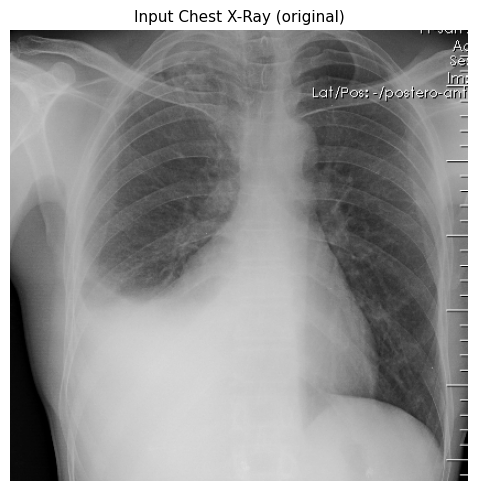

In [5]:
# ── Load sample chest X-ray ──────────────────────────────────────────────────
#
# SAMPLE_CXR_URL = (
#     "https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png"
# )
SAMPLE_CXR_URL = "https://prod-images-static.radiopaedia.org/images/5657723/2daed52f7226526bae750440a0aaef.png"

# ── Option A: Download from URL ───────────────────────────────────────────────
try:
    print("Fetching sample chest X-ray from Wikimedia Commons...")
    resp = requests.get(SAMPLE_CXR_URL, headers={"User-Agent": "CLARITY/1.0"}, timeout=30)
    resp.raise_for_status()
    xray_image = Image.open(BytesIO(resp.content)).convert("RGB")
    IMAGE_SOURCE = "Wikimedia Commons (CC0) — Chest_Xray_PA_3-8-2010.png"
    print(f"✓ Loaded from URL | Original size: {xray_image.size[0]}×{xray_image.size[1]} px")

except Exception as e:
    print(f"⚠ URL download failed: {e}")
    # ── Option B: Load from Kaggle NIH dataset (add dataset to notebook first) ──
    # Uncomment and add 'nih-chest-xrays' dataset to this notebook
    # import glob, random
    # paths = glob.glob("/kaggle/input/nih-chest-xrays/data/images_001/images/*.png")
    # xray_image = Image.open(random.choice(paths)).convert("RGB")

    # ── Fallback: synthetic placeholder ───────────────────────────────────────
    print("Generating synthetic X-ray placeholder for testing...")
    arr = np.random.randint(30, 180, (512, 512), dtype=np.uint8)
    arr = ndimage.gaussian_filter(arr.astype(float), sigma=20).astype(np.uint8)
    # Simulate lung fields and cardiac silhouette shapes
    cx, cy = 256, 256
    for r, v in [(80, 40), (60, 60), (30, 160)]:
        yy, xx = np.ogrid[:512, :512]
        mask = ((xx - cx)**2 + (yy - cy)**2) < r**2
        arr[mask] = np.clip(arr[mask].astype(int) + v, 0, 255).astype(np.uint8)
    xray_image = Image.fromarray(arr).convert("RGB")
    IMAGE_SOURCE = "Synthetic placeholder (for testing only)"
    print(f"✓ Synthetic image created: {xray_image.size[0]}×{xray_image.size[1]} px")

print(f"  Source: {IMAGE_SOURCE}")

# ── Display ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(xray_image, cmap="gray")
ax.set_title("Input Chest X-Ray (original)", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

In [63]:
# ── Step 1: Generate Radiology Report ────────────────────────────────────────

def build_messages(system_prompt, image):
    # Return a flat list of message dictionaries
    return [
        {"role": "system", "content": system_prompt},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "Analyze this X-ray."},
            ],
        }
    ]

def generate_report(model, processor, image, system_prompt, max_new_tokens=500):
    messages = build_messages(system_prompt, image)
    prompt_text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = processor(text=prompt_text, images=image, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.2,
            top_p=0.9,
            pad_token_id=processor.tokenizer.eos_token_id,
        )

    input_len = inputs["input_ids"].shape[1]
    generated_ids = output_ids[0, input_len:]
    report_text = processor.decode(generated_ids, skip_special_tokens=True).strip()

    return report_text, prompt_text

print("Generating diagnostic report...")
report_text, prompt_text = generate_report(model, processor, xray_image, SYSTEM_PROMPT, MAX_NEW_TOKENS)

print("\n" + "═"*65)
print("  CLARITY — FULL DIAGNOSTIC REPORT")
print("═"*65)
print(report_text)
print("═"*65)

Generating diagnostic report...

═════════════════════════════════════════════════════════════════
  CLARITY — FULL DIAGNOSTIC REPORT
═════════════════════════════════════════════════════════════════
1. Impression: Right pleural effusion.
2. Confidence: 95%.
3. Reasoning: There is a significant opacity in the right lower hemithorax, obscuring the right hemidiaphragm and right costophrenic angle, consistent with fluid accumulation in the pleural space.
4. Findings: The right lung field shows a large opacity obscuring the right hemidiaphragm and right costophrenic angle. The left lung field appears clear. The cardiac silhouette is normal in size and contour. The mediastinum is normal in width and alignment. The left costophrenic angle is clear. The visualized bony structures are unremarkable.
═════════════════════════════════════════════════════════════════


In [65]:
def parse_report_sentences(report_text, min_len=15):
    # Extract text after '4.' (Findings section)
    parts = report_text.split("4.")
    findings_text = parts[-1].strip() if len(parts) > 1 else report_text

    # 🔥 Remove "Findings:" (case-insensitive, safe)
    findings_text = re.sub(r'^\s*findings:\s*', '', findings_text, flags=re.IGNORECASE)

    # Sentence tokenize
    raw = sent_tokenize(findings_text)

    # Clean + filter
    sentences = [s.strip() for s in raw if len(s.strip()) >= min_len]

    return sentences

sentences = parse_report_sentences(report_text)

print(f"Parsed {len(sentences)} findings from the fourth section:\n")
for i, s in enumerate(sentences):
    print(f"  [{i:02d}]  {s}")

Parsed 6 findings from the fourth section:

  [00]  The right lung field shows a large opacity obscuring the right hemidiaphragm and right costophrenic angle.
  [01]  The left lung field appears clear.
  [02]  The cardiac silhouette is normal in size and contour.
  [03]  The mediastinum is normal in width and alignment.
  [04]  The left costophrenic angle is clear.
  [05]  The visualized bony structures are unremarkable.


In [64]:
# ── Step 3: Attention Map Extraction ─────────────────────────────────────────
#
# DESIGN NOTES:
#
# We do a single forward pass on the full sequence:
#   [image_patches (N_IMG_PATCHES)] [prompt tokens] [report tokens]
#
# With output_attentions=True and attn_implementation="eager", each decoder layer
# returns its attention weight matrix of shape:
#   (batch, num_heads, seq_len, seq_len)
#
# Key layout in the attention matrix:
#   - Columns 0  ..  N_IMG_PATCHES-1  : image patch KEY positions
#   - Columns N_IMG_PATCHES .. end    : text KEY positions
#
# We extract the slice:
#   attention[batch=0, :, text_query_positions, :N_IMG_PATCHES]
# This gives us: "for each text token, how much did it attend to each image patch?"
#
# Memory budget on T4 (16 GB):
#   4-bit model     : ~2.5 GB
#   bf16 activations: ~1.0 GB
#   34 layers × attn_matrix_size (bf16) ≈ 10-11 GB
#   Total estimate  : ~13.5 GB  →  fits in 16 GB
#
# If OOM: reduce N_LAYERS_FROM_END in CONFIG, or switch to QUANT_MODE="int4"
#

def extract_text_to_image_attention(
    model,
    processor,
    image,
    prompt_text,
    report_text,
    n_layers_from_end=6,
):
    """
    Build the full input sequence (prompt + report), run a forward pass with
    output_attentions=True, and return the text→image attention slice.

    Returns
    -------
    text_to_img_attn : torch.Tensor  shape (n_sel_layers, n_heads, n_text_tokens, N_img)
                       float32, on CPU
    suffix_input_ids : torch.Tensor  shape (n_text_tokens,)
                       the token IDs for the text suffix (after the image placeholder),
                       used for sentence → token index mapping
    """
    gc.collect()
    torch.cuda.empty_cache()

    # ── Build full sequence input ─────────────────────────────────────────────
    # Append the report to the formatted prompt.
    # processor will tokenize both and embed the image in-place.
    full_text = prompt_text + report_text

    inputs = processor(
        text=full_text,
        images=image,
        return_tensors="pt",
    ).to(model.device)

    input_ids    = inputs["input_ids"]        # (1, L)  — L includes 1 image placeholder
    pixel_values = inputs["pixel_values"]
    attn_mask    = inputs.get("attention_mask")

    # Gemma 3 expands the image into mm_tokens_per_image tokens (256) inside input_ids
    placeholder_positions = (input_ids[0] == model.config.image_token_index).nonzero(as_tuple=True)[0]
    if len(placeholder_positions) == 0:
        raise ValueError(
            f"IMAGE_TOKEN_ID={model.config.image_token_index} not found in input_ids. "
            "This usually means the processor did not insert an image token. "
            "Check that the chat template includes an image content block."
        )

    # Dynamically find image token boundaries
    img_attn_start = placeholder_positions[0].item()
    img_attn_end   = placeholder_positions[-1].item() + 1
    actual_img_patches = img_attn_end - img_attn_start

    # Text suffix strictly follows the last image patch
    text_attn_start = img_attn_end
    suffix_input_ids = input_ids[0, text_attn_start:].cpu()

    print("Forward pass configuration:")
    print(f"  input_ids length         : {input_ids.shape[1]}")
    print(f"  image patches in seq     : {actual_img_patches}")
    print(f"  image token range [attn] :[{img_attn_start}, {img_attn_end})")
    print(f"  text  token range [attn] :[{text_attn_start}, ...)")
    print(f"  suffix_input_ids length  : {suffix_input_ids.shape[0]}\n")
    print(f"Running forward pass (output_attentions=True) — may take 30-90 s...")

    # ── Forward pass ─────────────────────────────────────────────────────────
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            pixel_values=pixel_values,
            attention_mask=attn_mask,
            output_attentions=True,
            return_dict=True,
        )

    # outputs.attentions: tuple of (1, heads, expanded_seq_len, expanded_seq_len)
    n_total_layers = len(outputs.attentions)
    mid = n_total_layers // 2
    # Extract 6 layers exactly from the middle of the model
    selected_idxs = set(range(mid - 3, mid + 3))

    print(f"  Total decoder layers : {n_total_layers}")
    print(f"  Extracting layers    : {min(selected_idxs)} – {max(selected_idxs)}")

    text_to_img_list = []
    for layer_idx, layer_attn in enumerate(outputs.attentions):
        if layer_idx in selected_idxs:
            # layer_attn : (1, heads, expanded_seq_len, expanded_seq_len)
            # Slice: text queries → image keys
            t2i = layer_attn[0, :, text_attn_start:, img_attn_start:img_attn_end]
            # t2i : (heads, n_text_tokens, N_IMG_PATCHES)
            text_to_img_list.append(t2i.float().cpu())
        # Release GPU tensor immediately — critical for memory
        del layer_attn

    del outputs
    gc.collect()
    torch.cuda.empty_cache()

    # Stack → (n_selected_layers, heads, n_text_tokens, N_img)
    text_to_img_attn = torch.stack(text_to_img_list)

    if device == "cuda":
        used_gb = torch.cuda.memory_allocated() / 1e9
        total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"  GPU memory after extraction: {used_gb:.1f} / {total_gb:.1f} GB")

    print()
    print(f"✓ text_to_img_attn shape: {tuple(text_to_img_attn.shape)}")
    print(f"  (layers, heads, text_tokens, img_patches)")

    return text_to_img_attn, suffix_input_ids


text_to_img_attn, suffix_input_ids = extract_text_to_image_attention(
    model, processor, xray_image, prompt_text, report_text, N_LAYERS_FROM_END
)

Forward pass configuration:
  input_ids length         : 558
  image patches in seq     : 256
  image token range [attn] :[153, 409)
  text  token range [attn] :[409, ...)
  suffix_input_ids length  : 149

Running forward pass (output_attentions=True) — may take 30-90 s...
  Total decoder layers : 34
  Extracting layers    : 14 – 19
  GPU memory after extraction: 8.6 / 15.6 GB

✓ text_to_img_attn shape: (6, 8, 149, 256)
  (layers, heads, text_tokens, img_patches)


In [54]:
# Refresh visualizations for the updated findings
sentences = parse_report_sentences(report_text)
raw_maps = [compute_raw_heatmap(sent, suffix_input_ids, text_to_img_attn, processor) for sent in sentences]
global_avg_map = np.mean(raw_maps, axis=0)

sentence_heatmaps = {}
for i, sent in enumerate(sentences):
    contrastive_map = np.clip(raw_maps[i] - global_avg_map, 0, None)
    if ATTN_SIGMA > 0:
        contrastive_map = ndimage.gaussian_filter(contrastive_map, sigma=ATTN_SIGMA)
    h_min, h_max = contrastive_map.min(), contrastive_map.max()
    final_map = (contrastive_map - h_min) / (h_max - h_min) if (h_max - h_min) > 1e-8 else np.zeros_like(contrastive_map)
    ov = overlay_heatmap(xray_image, final_map)
    sentence_heatmaps[i] = {"heatmap": final_map, "overlay": ov, "sentence": sent}

print(f"\u2713 {len(sentence_heatmaps)} heatmaps refreshed.")
display(build_clarity_widget(xray_image, sentences, sentence_heatmaps))

✓ 5 heatmaps refreshed.


In [ ]:
# # ── Step 5: Precompute All Sentence Heatmaps ─────────────────────────────────
# #
# # We compute heatmaps for all sentences up-front so the interactive widget is
# # instant (no per-click compute).

# print(f"Precomputing heatmaps for {len(sentences)} sentences...\n")
# sentence_heatmaps = {}   # idx → {"heatmap": np.ndarray, "overlay": PIL.Image}

# for i, sent in enumerate(sentences):
#     print(f"  [{i+1:02d}/{len(sentences)}] {sent[:72]}{'...' if len(sent) > 72 else ''}")
#     hm = compute_heatmap(
#         sentence=sent,
#         suffix_input_ids=suffix_input_ids,
#         text_to_img_attn=text_to_img_attn,
#         processor=processor,
#     )
#     ov = overlay_heatmap(xray_image, hm)
#     sentence_heatmaps[i] = {"heatmap": hm, "overlay": ov, "sentence": sent}

# print(f"\n✓ Done — {len(sentence_heatmaps)} heatmaps ready.")

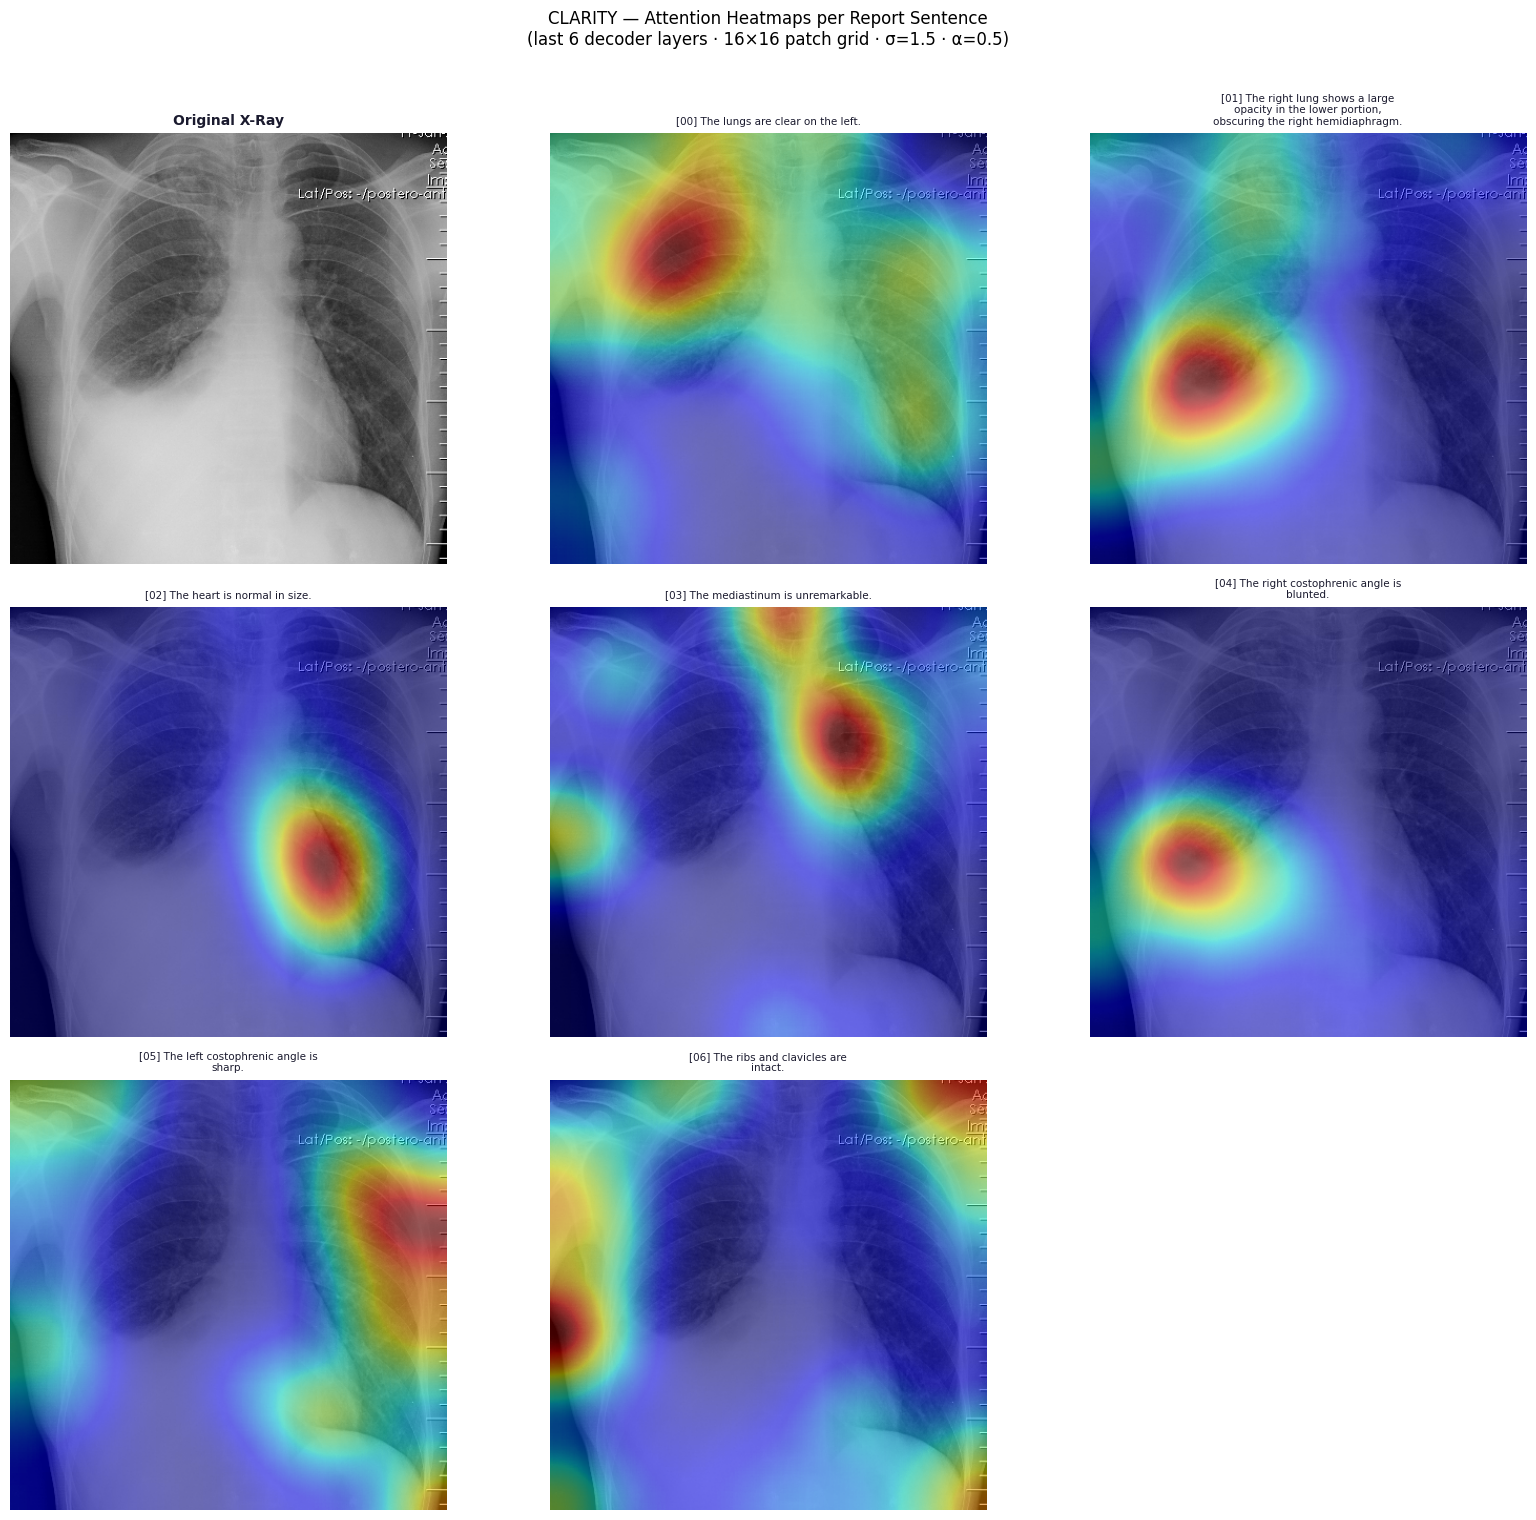

✓ Saved static grid → ./out/clarity_heatmaps_grid.png


In [47]:
# ── Step 6: Static Multi-Panel Visualization ─────────────────────────────────
#
# Renders a grid showing the original image plus heatmap overlays for each sentence.
# Saved as PNG so you can inspect / include in your report.

def plot_clarity_grid(xray_image, sentences, sentence_heatmaps, cols=3, max_sentences=9):
    n_show  = min(max_sentences, len(sentences))
    n_total = 1 + n_show                              # +1 for original image
    rows    = (n_total + cols - 1) // cols

    fig = plt.figure(figsize=(5.5 * cols, 5.0 * rows))
    fig.suptitle(
        "CLARITY — Attention Heatmaps per Report Sentence\n"
        f"(last {N_LAYERS_FROM_END} decoder layers · {PATCH_GRID}×{PATCH_GRID} patch grid · "
        f"σ={ATTN_SIGMA} · α={OVERLAY_ALPHA})",
        fontsize=12, y=1.01
    )

    # ── Original image ────────────────────────────────────────────────────────
    ax0 = fig.add_subplot(rows, cols, 1)
    ax0.imshow(xray_image, cmap="gray")
    ax0.set_title("Original X-Ray", fontsize=10, fontweight="bold", color="#1a1a2e")
    ax0.axis("off")

    # ── Sentence heatmaps ─────────────────────────────────────────────────────
    for i in range(n_show):
        ax = fig.add_subplot(rows, cols, i + 2)
        ax.imshow(sentence_heatmaps[i]["overlay"])
        title = textwrap.fill(f"[{i:02d}] {sentences[i]}", width=38)
        ax.set_title(title, fontsize=7.5, color="#1a1a2e")
        ax.axis("off")

    plt.tight_layout()
    out_path = "./out/clarity_heatmaps_grid.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved static grid → {out_path}")


plot_clarity_grid(xray_image, sentences, sentence_heatmaps, cols=3, max_sentences=9)

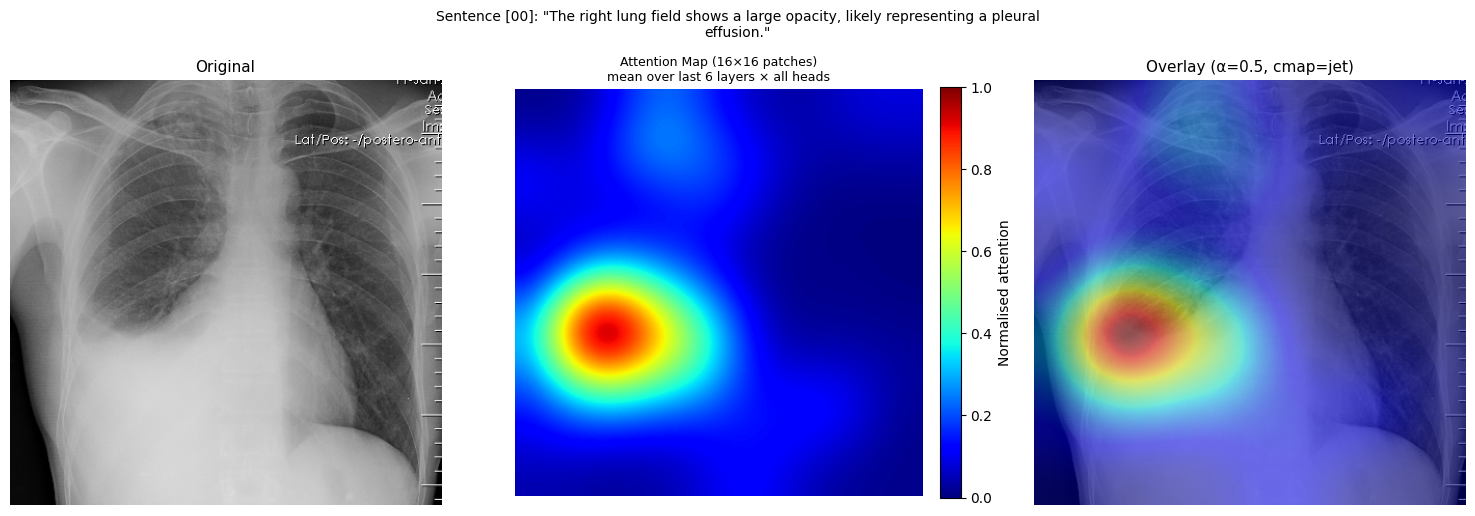

✓ Saved detail panel → ./out/clarity_sentence_00_detail.png


In [29]:
# ── Step 7: Detailed Triple-Panel for a Specific Sentence ────────────────────
# Change SENTENCE_IDX to inspect any sentence in detail.

SENTENCE_IDX = 0

def plot_sentence_detail(idx, xray_image, sentences, sentence_heatmaps, patch_grid=PATCH_GRID):
    """
    Three-panel plot: original | raw attention map | blended overlay.
    Also shows a colourbar so intensity values are interpretable.
    """
    sent = sentences[idx]
    hm   = sentence_heatmaps[idx]["heatmap"]
    ov   = sentence_heatmaps[idx]["overlay"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f'Sentence [{idx:02d}]: "{textwrap.fill(sent, 80)}"',
        fontsize=10, y=1.02
    )

    # Original
    axes[0].imshow(xray_image, cmap="gray")
    axes[0].set_title("Original", fontsize=11)
    axes[0].axis("off")

    # Raw attention map (patch resolution)
    im = axes[1].imshow(hm, cmap=HEATMAP_CMAP, interpolation="bicubic", vmin=0, vmax=1)
    axes[1].set_title(
        f"Attention Map ({patch_grid}×{patch_grid} patches)\n"
        f"mean over last {N_LAYERS_FROM_END} layers × all heads",
        fontsize=9
    )
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Normalised attention")

    # Blended overlay
    axes[2].imshow(ov)
    axes[2].set_title(f"Overlay (α={OVERLAY_ALPHA}, cmap={HEATMAP_CMAP})", fontsize=11)
    axes[2].axis("off")

    plt.tight_layout()
    out_path = f"./out/clarity_sentence_{idx:02d}_detail.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved detail panel → {out_path}")


plot_sentence_detail(SENTENCE_IDX, xray_image, sentences, sentence_heatmaps)

In [15]:
# ── Step 8: Interactive CLARITY Widget ───────────────────────────────────────
#
# Click a sentence button → heatmap overlay updates on the left.
# Mimics the rad_explain UX with the added spatial xAI layer.
# Works in Kaggle's Jupyter environment (ipywidgets v7/v8).

def build_clarity_widget(xray_image, sentences, sentence_heatmaps):
    """Assemble the interactive CLARITY panel widget."""

    # ── Widget components ─────────────────────────────────────────────────────
    header = widgets.HTML(
        value=(
            '<div style="font-family:sans-serif;padding:8px 0;">'
            '<h2 style="margin:0;color:#1a1a2e;">🩻 CLARITY</h2>'
            '<p style="margin:4px 0;color:#555;font-size:13px;">'
            'Click any sentence → attention heatmap updates on the left.</p>'
            '</div>'
        )
    )

    # Left panel: image output
    img_out = widgets.Output(layout=widgets.Layout(
        width="52%", border="1px solid #ccc", padding="4px"
    ))

    # Info strip below image
    info_strip = widgets.HTML(
        value='<p style="font-family:sans-serif;font-size:12px;color:#888;">'
              'Select a sentence to highlight the relevant region →</p>'
    )

    # Right panel: sentence buttons
    btn_style_default  = {"button_color": "#f0f4ff"}
    btn_style_selected = {"button_color": "#4361ee"}

    sent_btns = []
    for i, s in enumerate(sentences):
        label = f"[{i:02d}]  {s[:90]}{'…' if len(s) > 90 else ''}"
        btn = widgets.Button(
            description=label,
            layout=widgets.Layout(
                width="100%", min_height="44px", height="auto",
                margin="3px 0px", text_align="left"
            ),
            style=dict(button_color="#f0f4ff", font_size="11.5px"),
            tooltip=s,
        )
        sent_btns.append(btn)

    btn_box = widgets.VBox(
        sent_btns,
        layout=widgets.Layout(
            width="48%", overflow_y="auto", max_height="620px", padding="4px"
        )
    )

    # Detail output area (triple-panel shown below on click)
    detail_out = widgets.Output(
        layout=widgets.Layout(width="100%", margin="8px 0px")
    )

    # ── Initial state: show original image ───────────────────────────────────
    def render_image(img_pil, title="Original X-Ray"):
        with img_out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(5, 5))
            ax.imshow(img_pil, cmap="gray" if img_pil.mode == "L" else None)
            ax.set_title(title, fontsize=10)
            ax.axis("off")
            plt.tight_layout()
            plt.show()
            plt.close(fig)

    render_image(xray_image)

    # ── Click handler ─────────────────────────────────────────────────────────
    def make_handler(idx):
        def on_click(b):
            # Reset all buttons
            for btn in sent_btns:
                btn.style.button_color = "#f0f4ff"
            # Highlight selected
            b.style.button_color = "#4361ee"

            sent = sentences[idx]
            hm   = sentence_heatmaps[idx]["heatmap"]
            ov   = sentence_heatmaps[idx]["overlay"]

            # Update left image
            render_image(ov, title=f"Heatmap — Sentence [{idx:02d}]")

            # Update info strip
            info_strip.value = (
                f'<div style="font-family:sans-serif;background:#f8f9ff;"'
                f'padding:6px;border-left:3px solid #4361ee;margin:4px 0;">'
                f'<b style="color:#1a1a2e">Sentence [{idx:02d}]:</b> '
                f'<span style="color:#333">{sent}</span><br/>'
                f'<span style="color:#777;font-size:11px;">'
                f'Attention aggregated from last {N_LAYERS_FROM_END} decoder layers '
                f'across all {text_to_img_attn.shape[1]} heads. '
                f'Warm colours = high attention to that image region.</span>'
                f'</div>'
            )

            # Render triple-panel in detail area
            with detail_out:
                clear_output(wait=True)
                fig, axes = plt.subplots(1, 3, figsize=(13, 4))
                axes[0].imshow(xray_image, cmap="gray")
                axes[0].set_title("Original", fontsize=10); axes[0].axis("off")

                im = axes[1].imshow(hm, cmap=HEATMAP_CMAP, interpolation="bicubic",
                                    vmin=0, vmax=1)
                axes[1].set_title(
                    f"Attention Map ({PATCH_GRID}×{PATCH_GRID})", fontsize=10
                )
                axes[1].axis("off")
                plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

                axes[2].imshow(ov)
                axes[2].set_title(f"Overlay (α={OVERLAY_ALPHA})", fontsize=10)
                axes[2].axis("off")

                plt.suptitle(
                    textwrap.fill(f'[{idx:02d}] "{sent}"', width=90),
                    fontsize=9, y=1.02
                )
                plt.tight_layout()
                plt.show()
                plt.close(fig)

        return on_click

    for i, btn in enumerate(sent_btns):
        btn.on_click(make_handler(i))

    # ── Assemble ──────────────────────────────────────────────────────────────
    top_row = widgets.HBox(
        [img_out, btn_box],
        layout=widgets.Layout(width="100%", align_items="flex-start")
    )
    widget = widgets.VBox(
        [header, top_row, info_strip, detail_out],
        layout=widgets.Layout(width="100%", padding="8px")
    )
    return widget


clarity_widget = build_clarity_widget(xray_image, sentences, sentence_heatmaps)
display(clarity_widget)

In [16]:
# ── Step 9: Export All Outputs ───────────────────────────────────────────────

OUTPUT_DIR = "./out/clarity_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Original image
xray_image.save(f"{OUTPUT_DIR}/xray_original.png")

# Per-sentence outputs
for i, sent in enumerate(sentences):
    hm = sentence_heatmaps[i]["heatmap"]
    ov = sentence_heatmaps[i]["overlay"]
    ov.save(f"{OUTPUT_DIR}/sentence_{i:02d}_overlay.png")
    np.save(f"{OUTPUT_DIR}/sentence_{i:02d}_heatmap.npy", hm)

# JSON manifest — includes the new structured report and metadata
manifest = {
    "clarity_version"  : "1.1",
    "timestamp"        : datetime.now().isoformat(),
    "model"            : MODEL_ID,
    "xai_method"       : "decoder_self_attention_aggregation_contrastive",
    "n_layers_from_end": N_LAYERS_FROM_END,
    "attn_sigma"       : ATTN_SIGMA,
    "overlay_alpha"    : OVERLAY_ALPHA,
    "heatmap_cmap"     : HEATMAP_CMAP,
    "patch_grid"       : f"{PATCH_GRID}x{PATCH_GRID}",
    "n_img_patches"    : N_IMG_PATCHES,
    "image_source"     : IMAGE_SOURCE,
    "full_report"      : report_text,
    "parsed_sentences": sentences,
    "config": {
        "quant_mode": QUANT_MODE,
        "max_tokens": MAX_NEW_TOKENS
    }
}

with open(f"{OUTPUT_DIR}/manifest.json", "w") as fh:
    json.dump(manifest, fh, indent=2)

print(f"✓ Outputs saved to {OUTPUT_DIR}/")
print(f"  xray_original.png")
print(f"  sentence_XX_overlay.png   (×{len(sentences)})")
print(f"  sentence_XX_heatmap.npy   (×{len(sentences)})")
print(f"  manifest.json (updated with new structured data)")

✓ Outputs saved to ./out/clarity_outputs/
  xray_original.png
  sentence_XX_overlay.png   (×11)
  sentence_XX_heatmap.npy   (×11)
  manifest.json (updated with new structured data)


## Research Notes & Known Limitations

### What this method does
- Uses **decoder self-attention** from the last N layers of the Gemma 3 LM backbone.
- For each sentence Sᵢ in the report, selects the attention rows corresponding to Sᵢ's tokens.
- Averages over selected layers, attention heads, and sentence tokens → a flat vector of size N_IMG_PATCHES.
- Reshapes to a (PATCH_GRID × PATCH_GRID) spatial map, Gaussian-smooths, normalises.
- Upsamples with bicubic interpolation to the original image resolution.

### Known limitations

| Limitation | Notes |
|---|---|
| **Attention ≠ Attribution** | Attention weights reflect where the model "looked", not what caused the output. They can be noisy and don't have formal XAI guarantees (Jain & Wallace, 2019; Wiegreffe & Pinter, 2019). |
| **Aggregation loses head diversity** | Different heads may specialise for different visual concepts. Averaging flattens this. Visualising per-head maps is richer. |
| **Token match failures** | Tokenisation boundary effects can cause a sentence's tokens to not align perfectly with the suffix. The fallback uses all tokens, producing a global heatmap. |
| **Memory on T4** | The full attention pass for 4096 image tokens is tight (~13.5 GB). Reduce `N_LAYERS_FROM_END` or use `QUANT_MODE="int4"` if OOM. |
| **Causal attention asymmetry** | The Gemma decoder uses causal masking: earlier tokens cannot attend to later ones. Sentence Sᵢ attends to the image, but later sentences also "see" Sᵢ via the KV cache. This is expected. |

### Stronger alternatives to explore next
1. **Attention rollout** (Abnar & Zuidema, 2020) — propagates attention through layers multiplicatively, correcting for residual stream mixing.
2. **Per-head specialisation analysis** — cluster heads by their image-attention patterns to identify anatomy-specific heads.
3. **Gradient × Attention** (Chefer et al., 2021) — multiply attention by its relevance gradient for a more faithful attribution map.
4. **Contrastive attention** — compare attention for "cardiomegaly detected" vs. "cardiac silhouette is normal" to get a differential heatmap.
5. **MedGemma 1.5 bounding boxes** — `google/medgemma-1.5-4b-it` natively supports anatomical localization via bounding box tokens. Could be used as ground-truth annotation for evaluating attention quality.

### Citation
```bibtex
@article{sellergren2025medgemma,
  title={MedGemma Technical Report},
  author={Sellergren, Andrew and others},
  journal={arXiv preprint arXiv:2507.05201},
  year={2025}
}
@inproceedings{abnar2020quantifying,
  title={Quantifying Attention Flow in Transformers},
  author={Abnar, Samira and Zuidema, Willem},
  booktitle={ACL},
  year={2020}
}
```


In [19]:
# Install FastAPI, Uvicorn, and Pyngrok
!pip install -q fastapi uvicorn pyngrok nest_asyncio

In [67]:
import os
import io
import base64
import threading
import nest_asyncio
import uvicorn
from fastapi import FastAPI, Request, Response, HTTPException, UploadFile, File
from fastapi.responses import JSONResponse
from pydantic import BaseModel
from PIL import Image
import numpy as np
import requests
from pyngrok import ngrok
import asyncio

# Apply nest_asyncio to allow uvicorn to run in a Jupyter environment
nest_asyncio.apply()

app = FastAPI()
server_instance = None
stop_event = threading.Event()

@app.post("/analyze")
async def generate_clarity_report_endpoint(file: UploadFile = File(...)):
    try:
        print(f"Processing uploaded file: {file.filename}")
        contents = await file.read()
        xray_image_pil = Image.open(io.BytesIO(contents)).convert("RGB")

        # Encode the original image to base64
        buffered_orig = io.BytesIO()
        xray_image_pil.save(buffered_orig, format="PNG")
        original_image_b64 = base64.b64encode(buffered_orig.getvalue()).decode("utf-8")

        # Standard processing pipeline
        report_text, prompt_text = generate_report(model, processor, xray_image_pil, SYSTEM_PROMPT, MAX_NEW_TOKENS)

        # Parse structured fields from the report
        # Expected format: 1. Impression 2. Confidence 3. Reasoning 4. Findings

        parts = report_text.split("\n")
        def extract_section(parts, section_num, label,is_confidence=False):
            for s in parts:
                if f"{section_num}." in s:
                  # Get text after "1." / "2." / "3."
                    text = s.split(f"{section_num}", 1)[-1].strip()

                    # 🔥 Remove label like "Impression:", "Confidence:"
                    text = re.sub(rf'^\s*{label}\s*[:\-]?\s*', '', text, flags=re.IGNORECASE)

                    if is_confidence:
                        text = re.sub(r'[^0-9.]', '', text)
                    return text
            return "N/A"

        impression = extract_section(parts, 1, "Impression")
        confidence = extract_section(parts, 2, "Confidence", is_confidence=True)
        reasoning  = extract_section(parts, 3, "Reasoning")

        sentences = parse_report_sentences(report_text)
        text_to_img_attn, suffix_input_ids = extract_text_to_image_attention(model, processor, xray_image_pil, prompt_text, report_text)

        raw_maps = [compute_raw_heatmap(sent, suffix_input_ids, text_to_img_attn, processor) for sent in sentences]
        global_avg_map = np.mean(raw_maps, axis=0)

        results = {
            "report_text": report_text,
            "impression": impression,
            "confidence": confidence,
            "reasoning": reasoning,
            "sentences": [],
            "original_image_b64": original_image_b64,
            "metadata": {"model_id": MODEL_ID}
        }

        for i, sent in enumerate(sentences):
            contrastive_map = np.clip(raw_maps[i] - global_avg_map, 0, None)
            if ATTN_SIGMA > 0:
                contrastive_map = ndimage.gaussian_filter(contrastive_map, sigma=ATTN_SIGMA)

            h_min, h_max = contrastive_map.min(), contrastive_map.max()
            final_map = (contrastive_map - h_min) / (h_max - h_min) if (h_max - h_min) > 1e-8 else np.zeros_like(contrastive_map)

            overlay_pil = overlay_heatmap(xray_image_pil, final_map)
            buffered = io.BytesIO()
            overlay_pil.save(buffered, format="PNG")

            results["sentences"].append({
                "sentence_text": sent,
                "heatmap_data": final_map.tolist(),
                "overlay_image_b64": base64.b64encode(buffered.getvalue()).decode("utf-8"),
            })
        return JSONResponse(content=results)
    except Exception as e:
        print(f"Error: {str(e)}")
        raise HTTPException(status_code=500, detail=str(e))

@app.post("/shutdown")
async def shutdown():
    ngrok.kill()
    asyncio.get_event_loop().call_later(1, lambda: stop_event.set())
    return {"message": "Server stopping."}

class CustomServer(uvicorn.Server):
    def install_signal_handlers(self):
        pass
    async def serve(self, sockets=None):
        process = asyncio.create_task(super().serve(sockets=sockets))
        while not stop_event.is_set():
            await asyncio.sleep(0.5)
        self.should_exit = True
        await process

def run_uvicorn():
    global server_instance
    stop_event.clear()
    config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="error")
    server_instance = CustomServer(config=config)
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    loop.run_until_complete(server_instance.serve())

# Start Server in background
threading.Thread(target=run_uvicorn, daemon=True).start()

# Setup ngrok
try:
    from google.colab import userdata
    ngrok.set_auth_token(userdata.get("NGROK_AUTH_TOKEN"))
    public_url = ngrok.connect(8000).public_url
    print(f"API: {public_url}/analyze")
except Exception as e:
    print(f"Ngrok Error: {e}")

API: https://exquisite-maternity-graceless.ngrok-free.dev/analyze


In [15]:
print("Hii")

Hii


In [46]:
# Summary of the generated CLARITY analysis
print(f"IMPRESSION: {sentences[0]}")
print("\nSENTENCE CONFIDENCE SCORES:")
for i, sent in enumerate(sentences):
    if '%' in sent:
        print(f"- {sent}")

print(f"\nREASONING:\n{report_text.split('**Reasoning:**')[-1].strip()}")

IMPRESSION: The lungs are clear on the left.

SENTENCE CONFIDENCE SCORES:

REASONING:
1. Right pleural effusion.
2. 95%
3. The right costophrenic angle is blunted, suggesting a pleural effusion. The right lung base is opacified, consistent with fluid accumulation. The left lung appears clear. The cardiac silhouette is normal in size. The mediastinum is unremarkable. The left costophrenic angle is clear. The ribs and clavicles appear normal.
4. The right lung field shows a large opacity in the lower portion, obscuring the right hemidiaphragm. The left lung field is clear. The cardiac silhouette is normal. The mediastinum is unremarkable. The left costophrenic angle is clear. The ribs and clavicles appear normal.
